In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from my_funcs.hellwig import hellwig_compensational
from preprocessing.WDI_hellwig import D0, df_panel, pattern, stim_or_destim


START PROGRAMU
KONIEC PROGRAMU


In [3]:
def print_head_tail(df, head = 5, tail = 5):
    df = df.sort_values(ascending=False)
    print(f"Head ({df.head(head)}\n")
    print(f"Tail ({df.tail(tail)}")
    return None

def print_scores(score):
    score = score.sort_values(ascending=False)
    for value, country in score.items():
        print(f"{value}: {country}")
    return None

In [4]:
pd.set_option("display.float_format", "{:.6f}".format)

In [5]:
year = ["2000", "2010", "2020"]
year = year[2]
df_fin = (
    df_panel[df_panel["Year"] == year]
    .drop(columns=["Year"])
    .set_index("Country Name")
)
year

'2020'

In [6]:
df = df_fin.copy()

In [7]:
q, score, deviations, _,_ = hellwig_compensational(
    df,
    stim_or_destim,
    pattern,
    D0)   

q.sort_values(ascending=False).tail(10)

Country Name
South Sudan             0.082600
Iraq                    0.069000
Gabon                   0.057200
Congo, Rep.             0.056100
Syrian Arab Republic    0.021000
Libya                   0.008900
Somalia                 0.003700
Chad                   -0.003200
Equatorial Guinea      -0.009400
Yemen, Rep.            -0.025500
dtype: float64

In [8]:
country = "Congo, Dem. Rep."   # albo sprawdź niżej, czy kraj nie jest zapisany inaczej

ranking = (
    q
    .sort_values(ascending=False)
    .rename("Hellwig_score")
    .to_frame()
)

ranking["rank"] = range(1, len(ranking) + 1)

ranking.loc[country]

Hellwig_score     0.154000
rank            165.000000
Name: Congo, Dem. Rep., dtype: float64

In [9]:
len(ranking)

194

### wzorce heatmapa


In [10]:
def get_pattern(year):
    df_year = (
        df_panel[df_panel["Year"] == str(year)]
        .drop(columns=["Year"])
        .set_index("Country Name")
    )

    p = pd.Series(index=pattern.index, dtype=float)

    stim_cols = stim_or_destim.loc[
        stim_or_destim["type"] == "stim", "variable"
    ]

    destim_cols = stim_or_destim.loc[
        stim_or_destim["type"] == "destim", "variable"
    ]

    p.loc[stim_cols] = df_year[stim_cols].max()
    p.loc[destim_cols] = df_year[destim_cols].min()

    return p

pattern_2000 = get_pattern(2000)
pattern_2010 = pattern.copy()
pattern_2020 = get_pattern(2020)

In [11]:
patterns = pd.DataFrame({
    "2000": pattern_2000,
    "2010": pattern_2010,
    "2020": pattern_2020
})

pattern_change = patterns.subtract(patterns["2010"], axis=0)

destim_cols = stim_or_destim.loc[
    stim_or_destim["type"] == "destim", "variable"
]

pattern_change.loc[destim_cols] *= -1

pattern_change = pattern_change.loc[
    pattern_change[["2000", "2020"]]
    .abs()
    .max(axis=1)
    .sort_values(ascending=False)
    .index
]

pattern_change.head()

,2000,2010,2020
"Industry (including construction), value added (annual % growth)",0.025226,0.000000,0.500969
Crop production index (2014-2016 = 100),0.465378,0.000000,0.019296
"Agriculture, forestry, and fishing, value added (annual % growth)",-0.045787,0.000000,0.422760
GDP per capita growth (annual %),0.412207,0.000000,0.173917
Statistical performance indicators (SPI): Pillar 1 data use score (scale 0-100),-0.040996,0.000000,0.400000


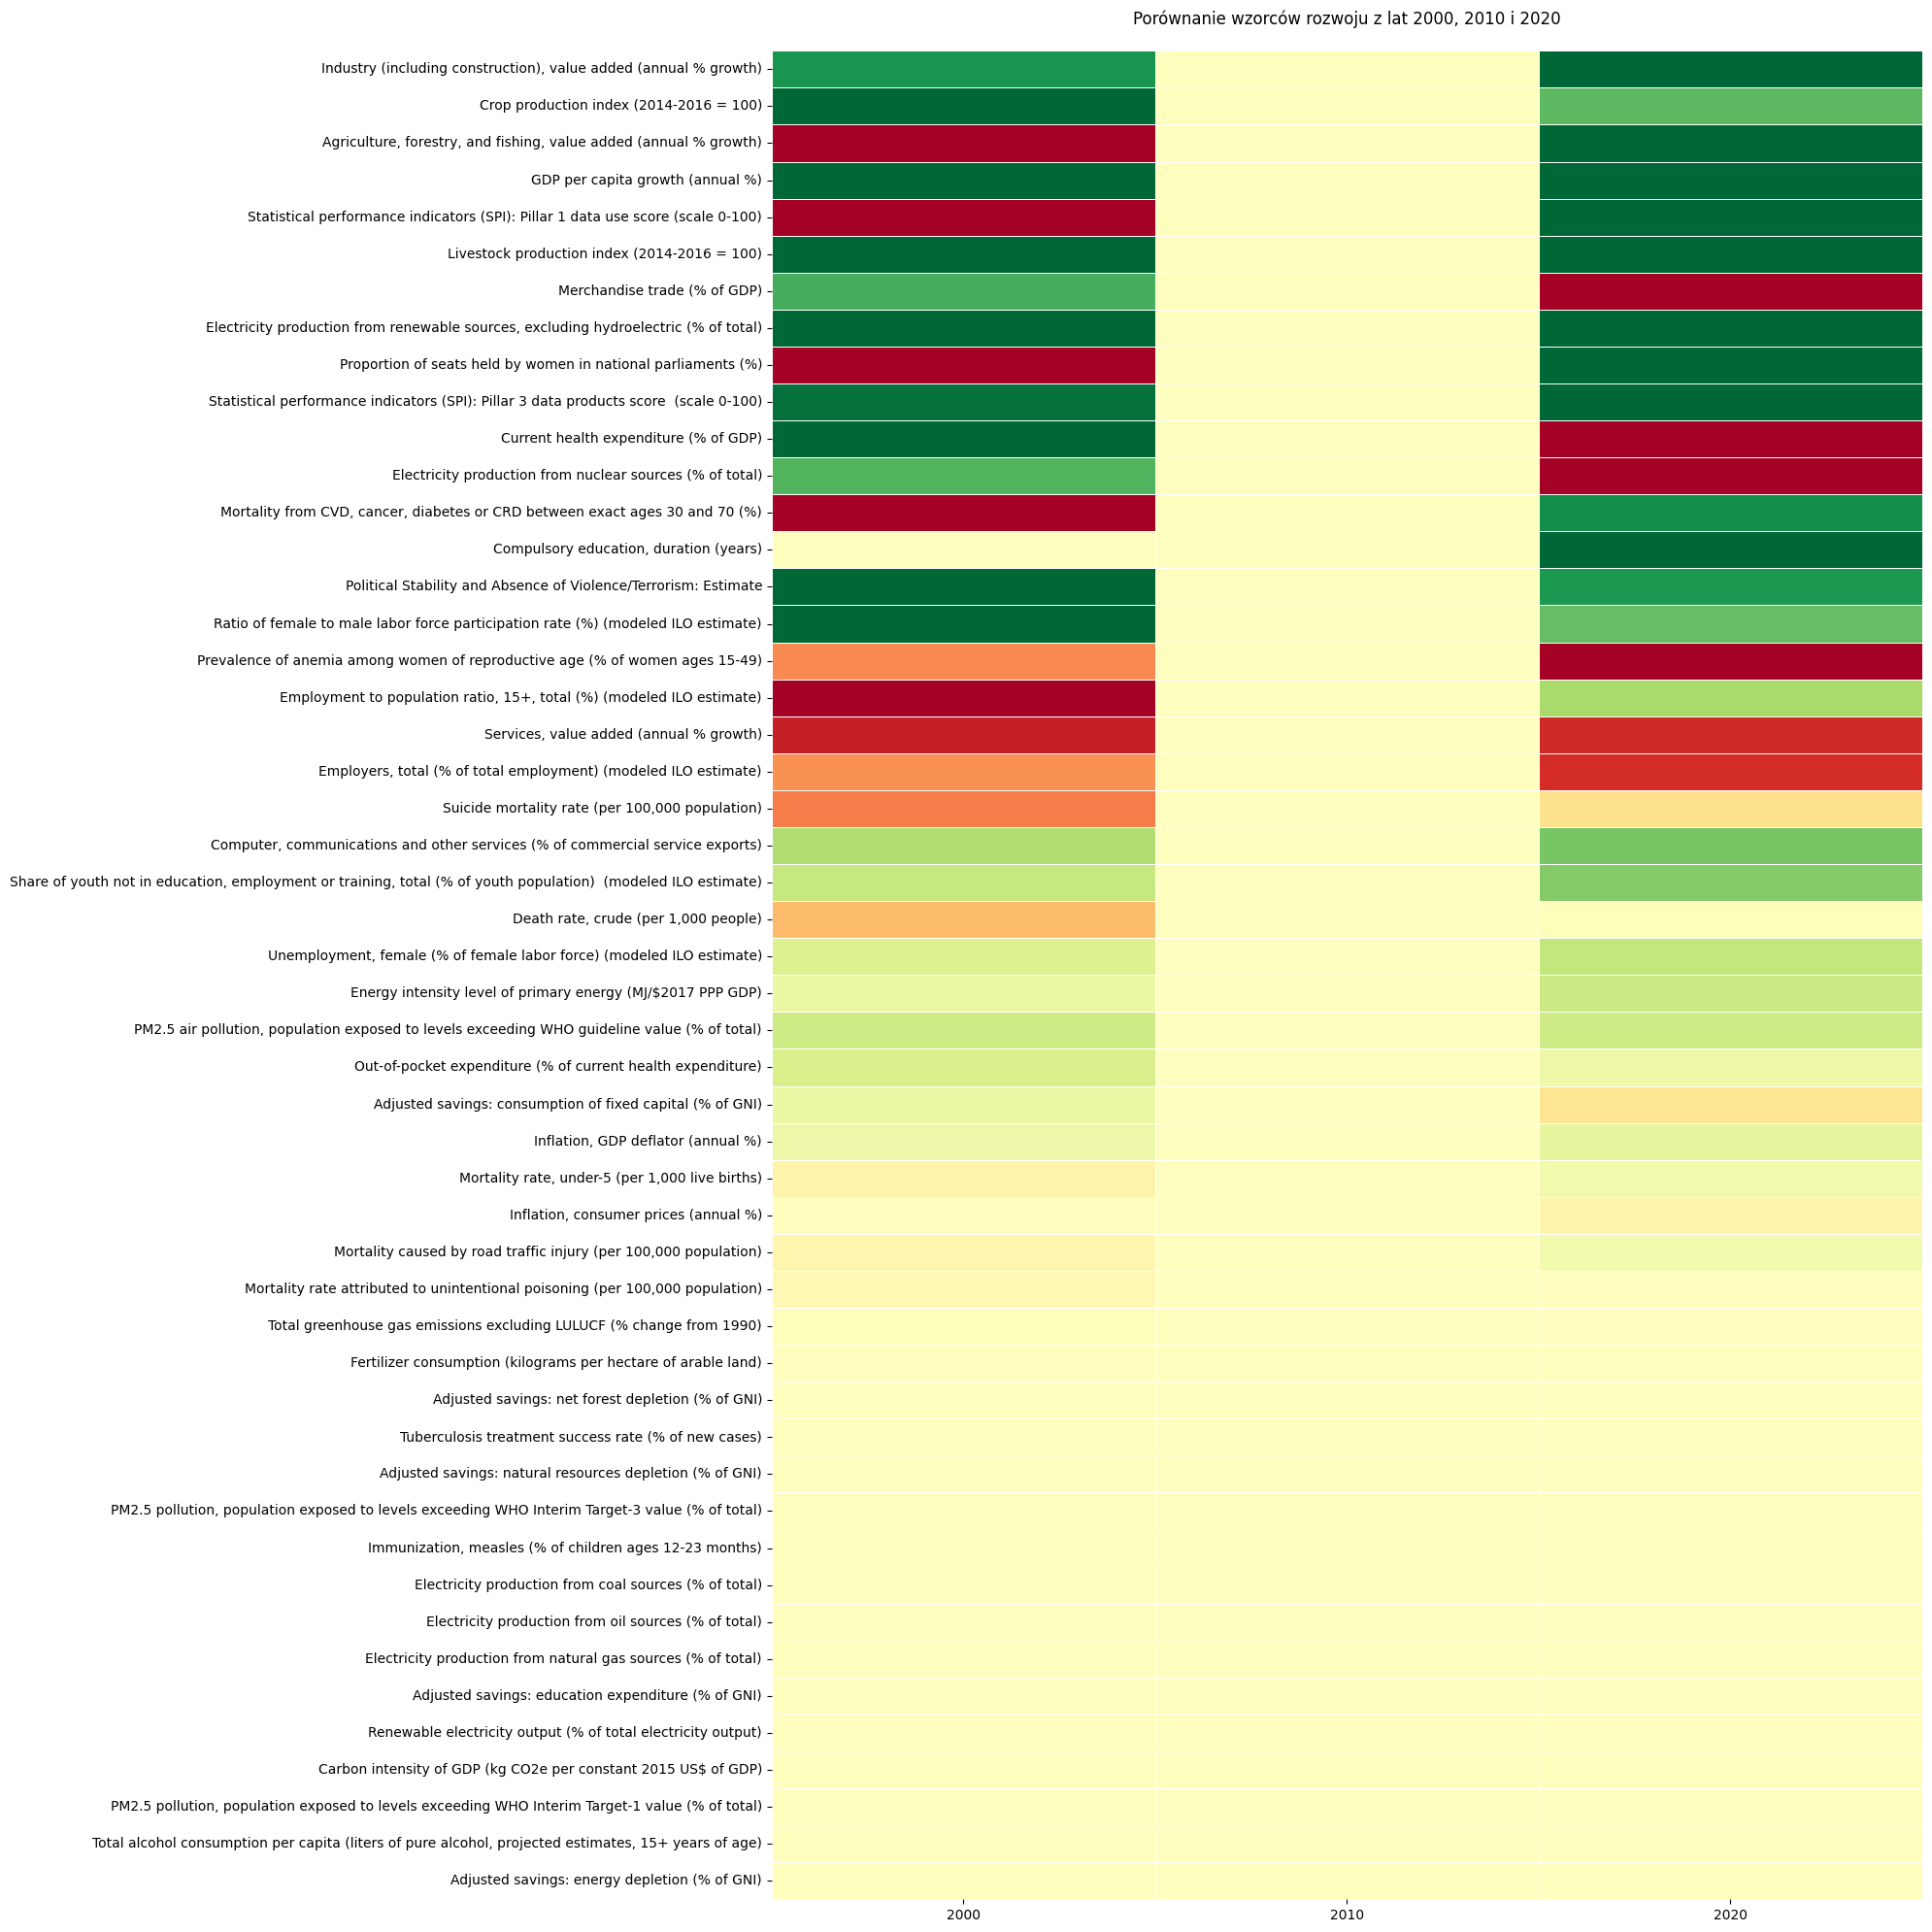

In [25]:
vals = np.abs(
    pattern_change[["2000", "2020"]]
    .to_numpy()
    .flatten()
)

limit = np.percentile(vals, 75)

plt.figure(figsize=(20, 20))

ax = sns.heatmap(
    pattern_change,
    cmap="RdYlGn",
    center=0,
    vmin=-limit,
    vmax=limit,
    linewidths=0.4,
    cbar=False,
    yticklabels=True,
    xticklabels=True
)

plt.title("Porównanie wzorców rozwoju z lat 2000, 2010 i 2020", pad=20)
plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()

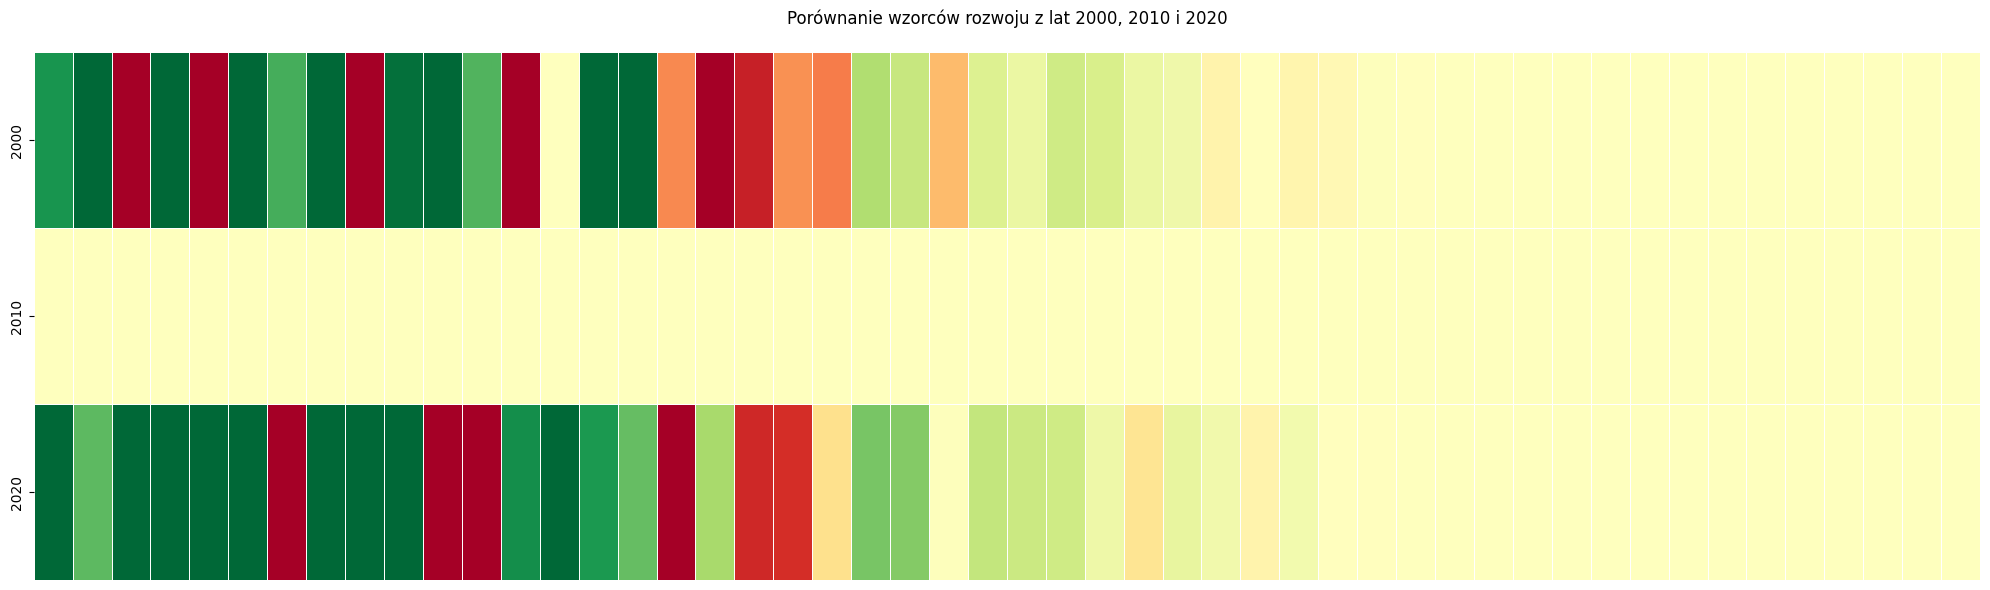

In [13]:
vals = np.abs(
    pattern_change[["2000", "2020"]]
    .to_numpy()
    .flatten()
)

limit = np.percentile(vals, 75)

plt.figure(figsize=(20, 6))

ax = sns.heatmap(
    pattern_change.T,
    cmap="RdYlGn",
    center=0,
    vmin=-limit,
    vmax=limit,
    linewidths=0.4,
    cbar=False,
    yticklabels=True,
    xticklabels=False
)

plt.title("Porównanie wzorców rozwoju z lat 2000, 2010 i 2020", pad=20)
plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()

### Szwecja


In [14]:
sweden = (
    df_panel[
        (df_panel["Country Name"] == "Sweden") &
        (df_panel["Year"].isin(["2010", "2020"]))
    ]
    .set_index("Year")
)

sweden_2010 = sweden.loc["2010", pattern.index].astype(float)
sweden_2020 = sweden.loc["2020", pattern.index].astype(float)

sweden_change = pd.DataFrame({
    "2010": sweden_2010 - pattern,
    "2020": sweden_2020 - pattern
})

destim_cols = stim_or_destim.loc[
    stim_or_destim["type"] == "destim", "variable"
]

sweden_change.loc[destim_cols] *= -1

sweden_change["zmiana"] = sweden_change["2020"] - sweden_change["2010"]

In [15]:
top10_sweden = (
    sweden_change
    .assign(abs_zmiana=sweden_change["zmiana"].abs())
    .sort_values("abs_zmiana", ascending=False)
    .head(10)
    .sort_values("abs_zmiana", ascending=True)
)

top10_sweden

,2010,2020,zmiana,abs_zmiana
"PM2.5 air pollution, population exposed to levels exceeding WHO guideline value (% of total)",-0.035910,-0.105081,-0.069171,0.069171
"Compulsory education, duration (years)",-0.538462,-0.461538,0.076923,0.076923
"Electricity production from renewable sources, excluding hydroelectric (% of total)",-0.242590,-0.161178,0.081412,0.081412
Electricity production from nuclear sources (% of total),-0.455424,-0.566941,-0.111517,0.111517
"Computer, communications and other services (% of commercial service exports)",-0.233759,-0.110069,0.123690,0.123690
Current health expenditure (% of GDP),-0.569471,-0.439156,0.130315,0.130315
Renewable electricity output (% of total electricity output),-0.446721,-0.315193,0.131528,0.131528
Tuberculosis treatment success rate (% of new cases),-0.120000,-0.280000,-0.160000,0.160000
Statistical performance indicators (SPI): Pillar 3 data products score (scale 0-100),-0.252147,0.044794,0.296941,0.296941
Statistical performance indicators (SPI): Pillar 1 data use score (scale 0-100),0.000000,0.400000,0.400000,0.400000


### Szwecja full

In [16]:
sweden = (
    df_panel[
        (df_panel["Country Name"] == "Sweden") &
        (df_panel["Year"].isin(["2000", "2010", "2020"]))
    ]
    .set_index("Year")
)

sweden_2000 = sweden.loc["2000", pattern.index].astype(float)
sweden_2010 = sweden.loc["2010", pattern.index].astype(float)
sweden_2020 = sweden.loc["2020", pattern.index].astype(float)

sweden_change = pd.DataFrame({
    "2000": sweden_2000 - pattern,
    "2010": sweden_2010 - pattern,
    "2020": sweden_2020 - pattern
})

destim_cols = stim_or_destim.loc[
    stim_or_destim["type"] == "destim", "variable"
]

sweden_change.loc[destim_cols] *= -1

sweden_change["zakres"] = (
    sweden_change[["2000", "2010", "2020"]].max(axis=1) -
    sweden_change[["2000", "2010", "2020"]].min(axis=1)
)

sweden_change = sweden_change.sort_values("zakres")

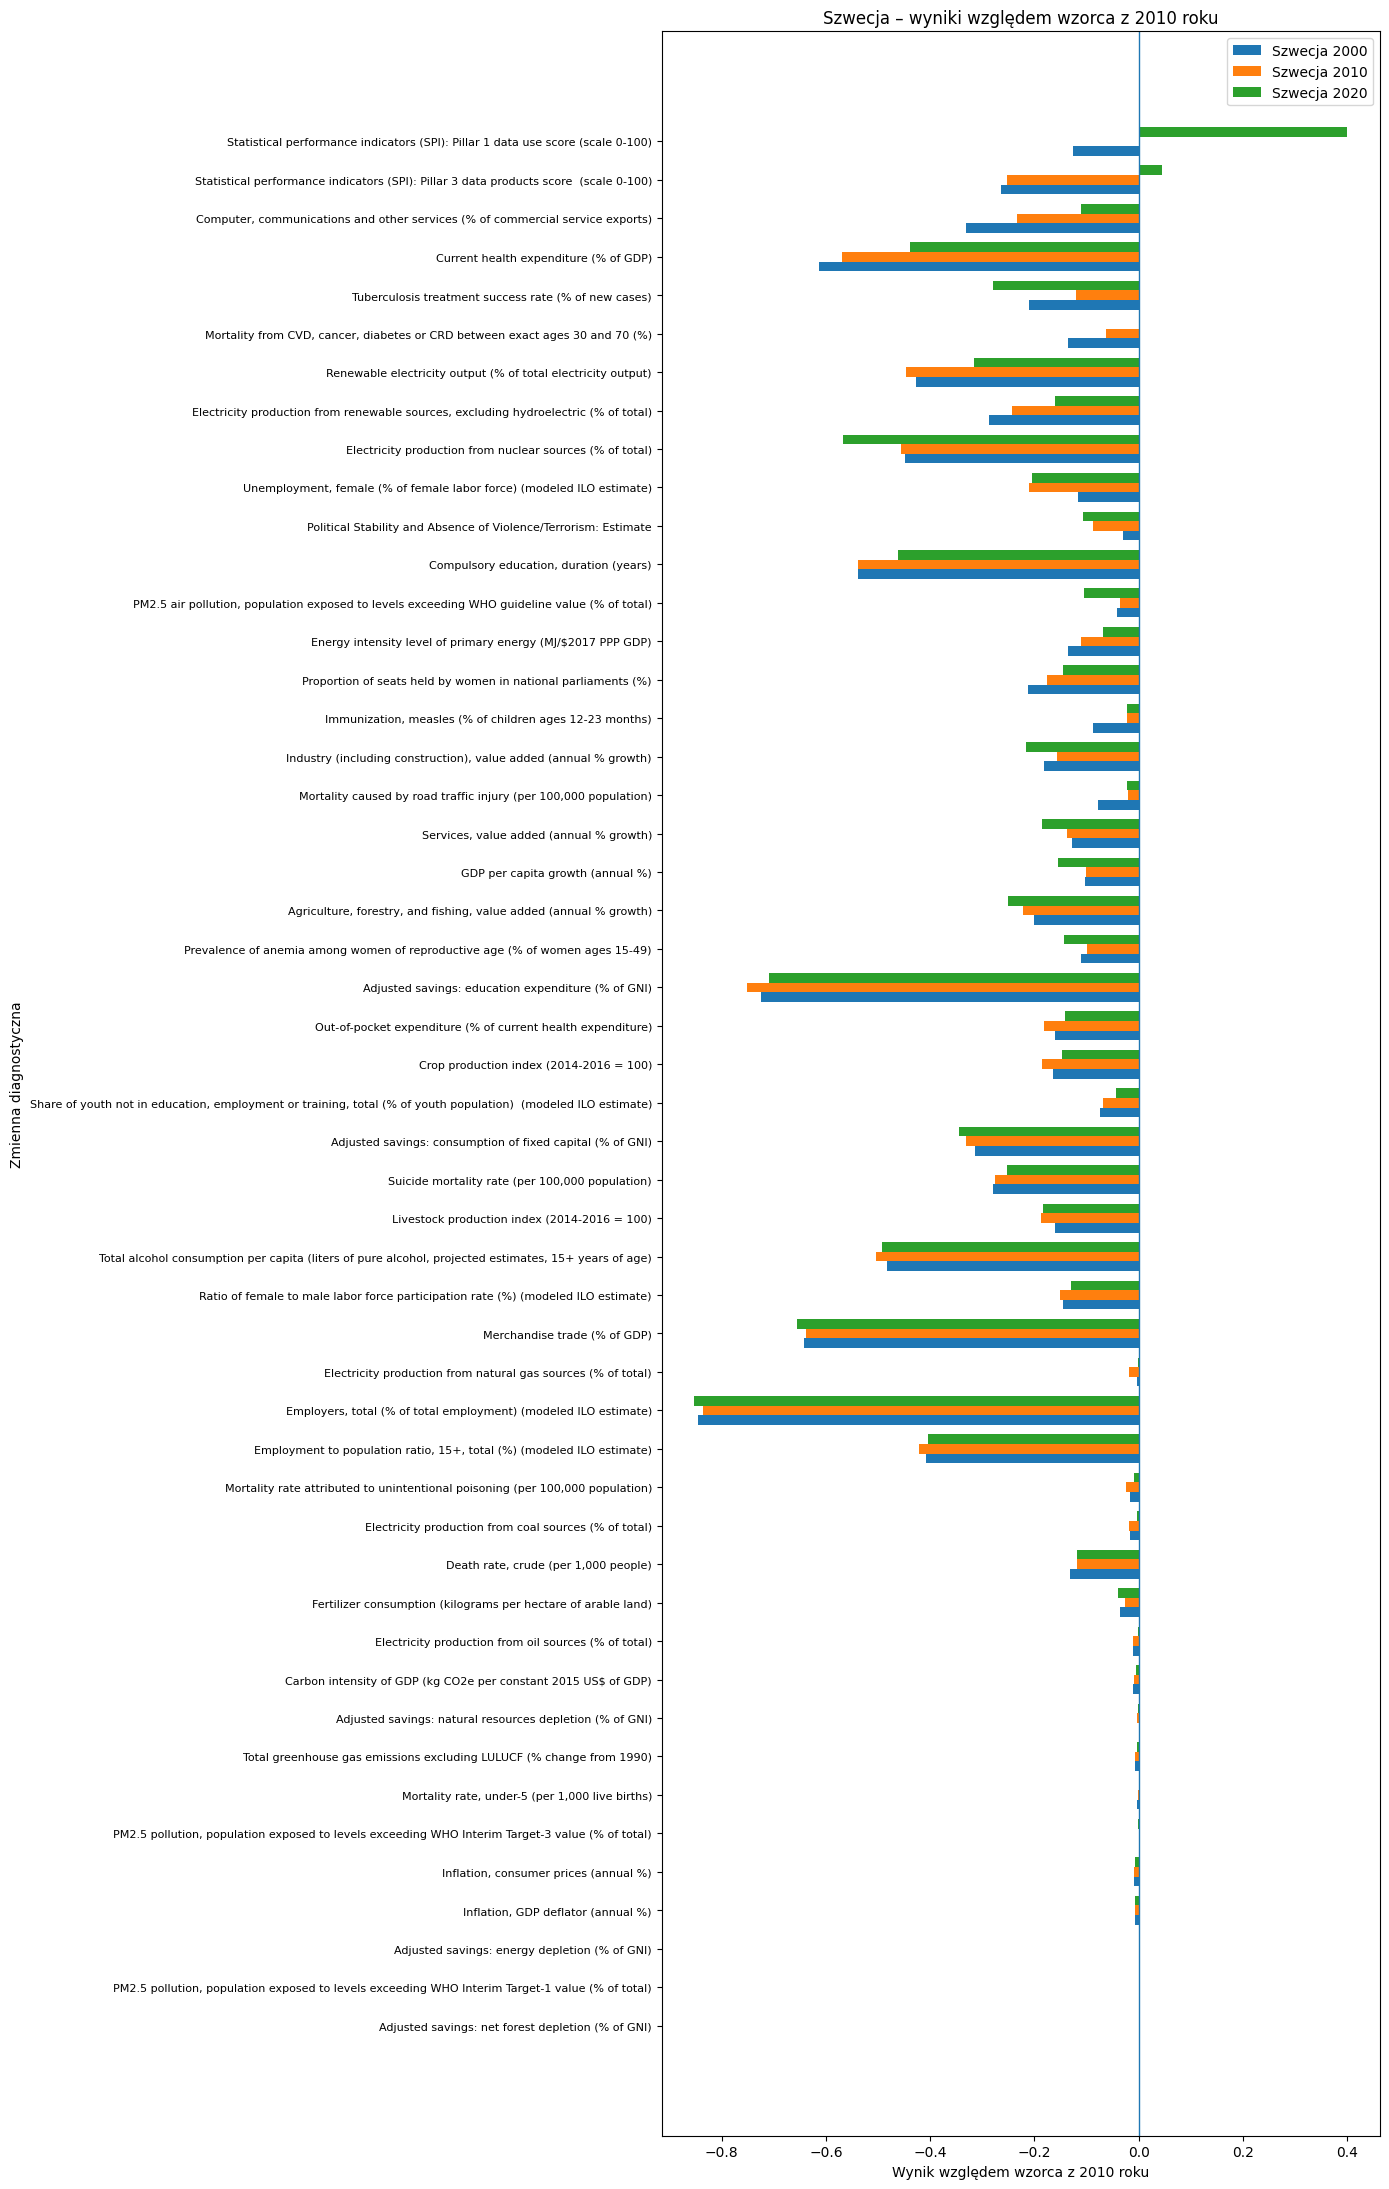

In [17]:
y = np.arange(len(sweden_change))
height = 0.25

plt.figure(figsize=(14, 22))

plt.barh(
    y - height,
    sweden_change["2000"],
    height=height,
    label="Szwecja 2000"
)

plt.barh(
    y,
    sweden_change["2010"],
    height=height,
    label="Szwecja 2010"
)

plt.barh(
    y + height,
    sweden_change["2020"],
    height=height,
    label="Szwecja 2020"
)

plt.axvline(0, linewidth=1)

plt.yticks(y, sweden_change.index, fontsize=8)

plt.xlabel("Wynik względem wzorca z 2010 roku")
plt.ylabel("Zmienna diagnostyczna")
plt.title("Szwecja – wyniki względem wzorca z 2010 roku")
plt.legend()

plt.tight_layout()
plt.show()

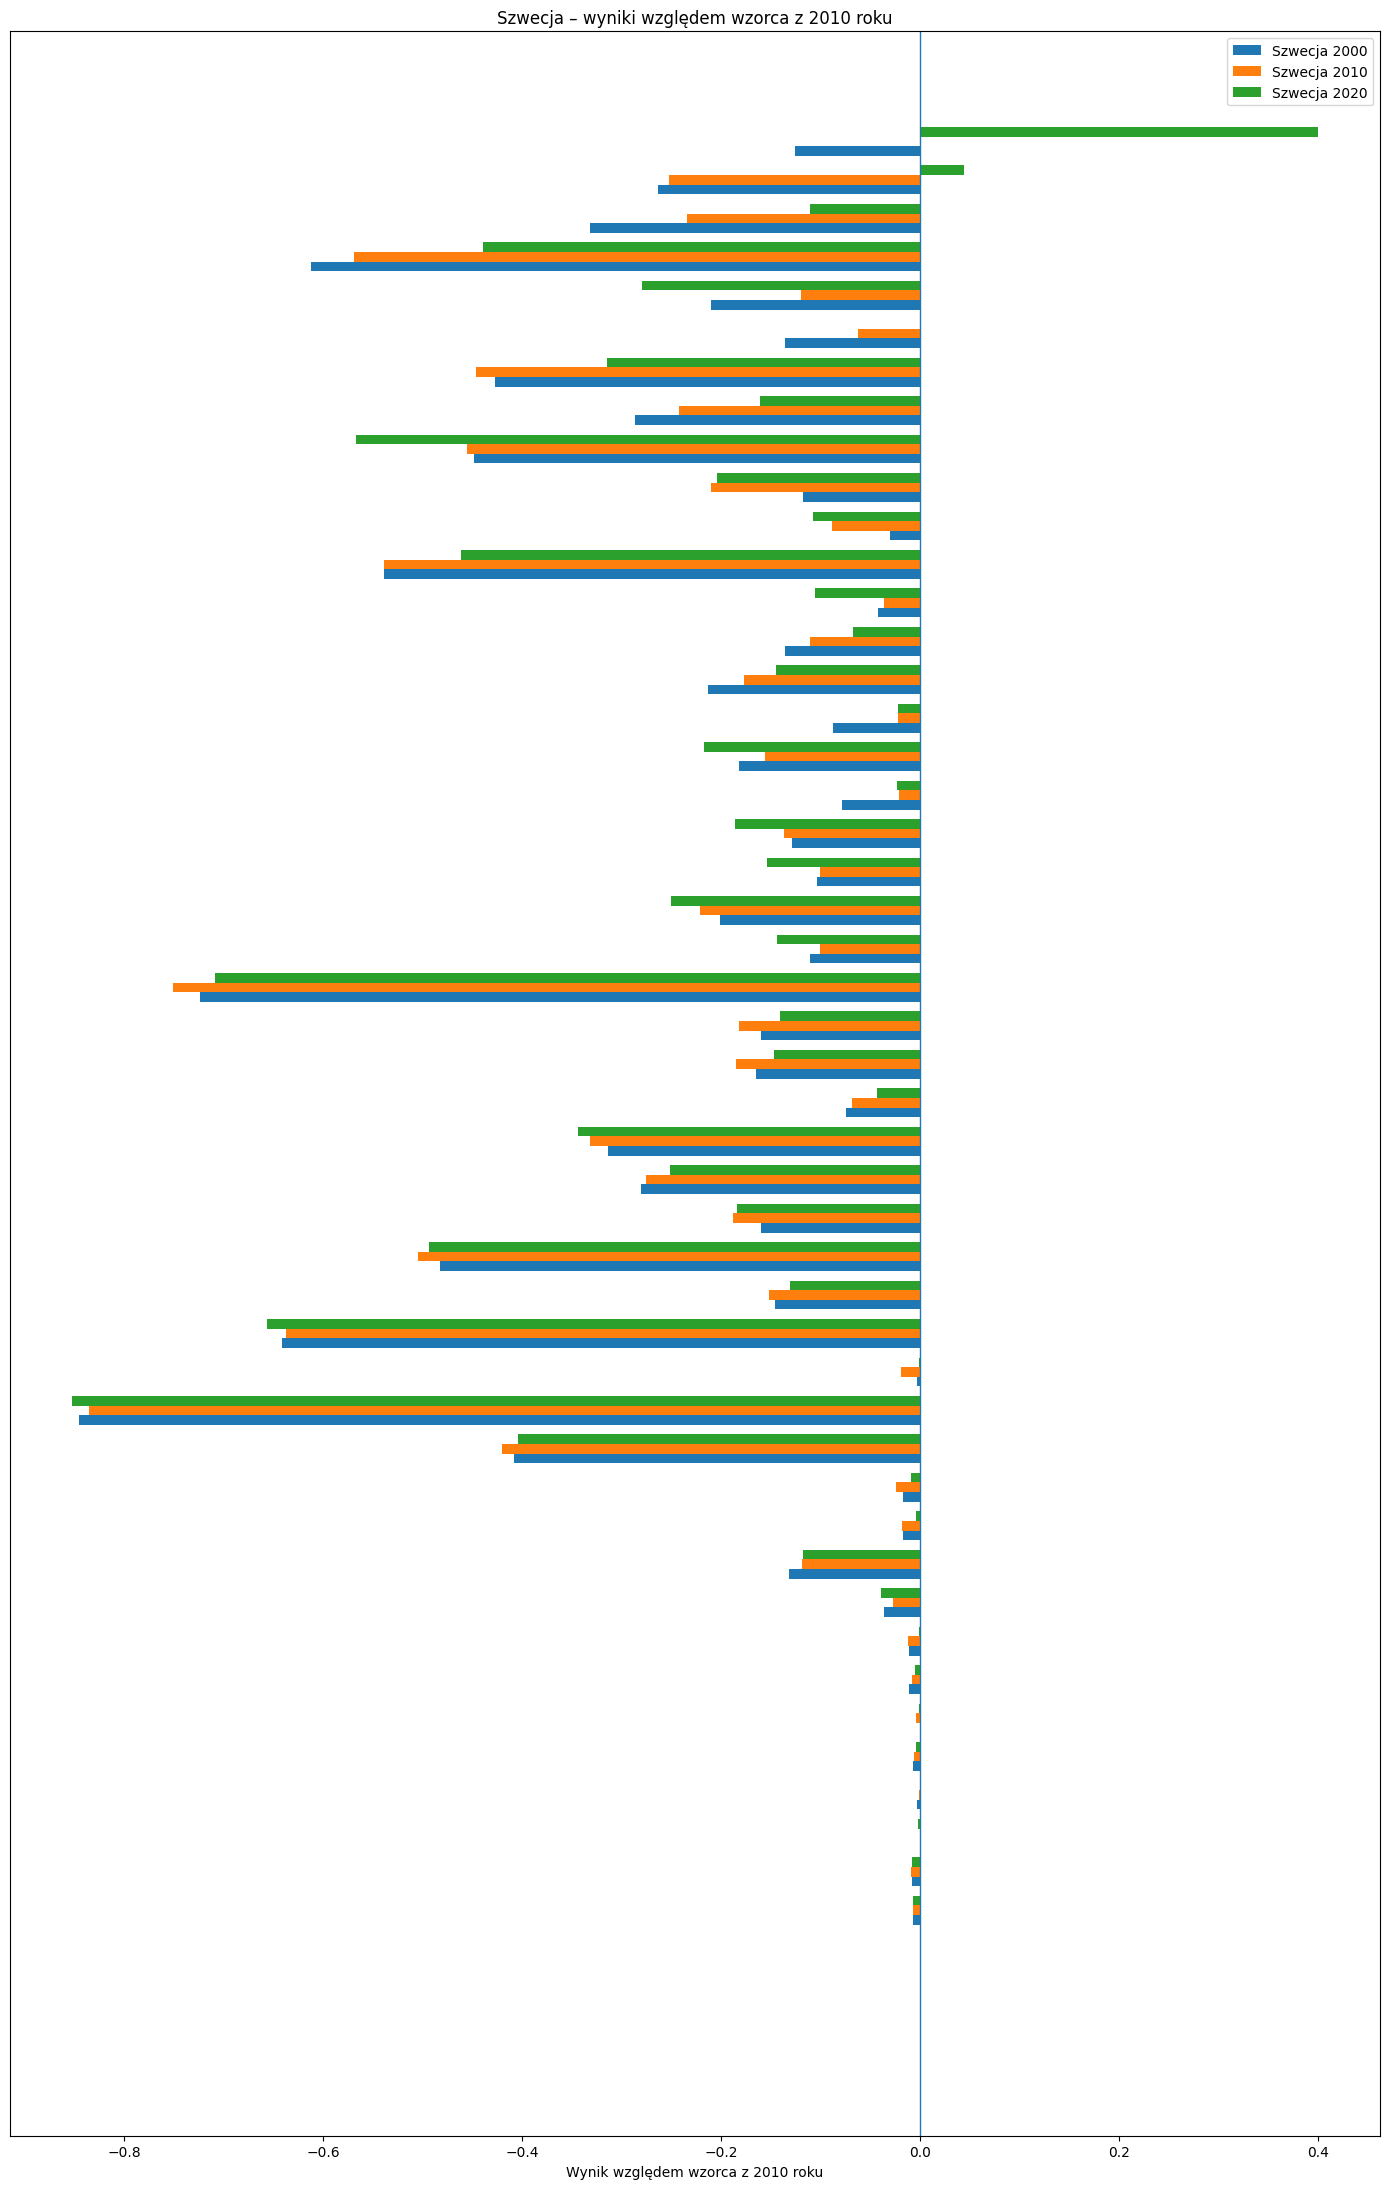

In [18]:
y = np.arange(len(sweden_change))
height = 0.25

plt.figure(figsize=(14, 22))

plt.barh(
    y - height,
    sweden_change["2000"],
    height=height,
    label="Szwecja 2000"
)

plt.barh(
    y,
    sweden_change["2010"],
    height=height,
    label="Szwecja 2010"
)

plt.barh(
    y + height,
    sweden_change["2020"],
    height=height,
    label="Szwecja 2020"
)

plt.axvline(0, linewidth=1)

plt.yticks([])

plt.xlabel("Wynik względem wzorca z 2010 roku")
plt.ylabel("")
plt.title("Szwecja – wyniki względem wzorca z 2010 roku")
plt.legend()

plt.tight_layout()
plt.show()

### TREND

In [19]:
import matplotlib.pyplot as plt

years = [str(y) for y in range(2000, 2021)]

results = []

for year in years:
    df_year = (
        df_panel[df_panel["Year"] == year]
        .drop(columns=["Year"])
        .set_index("Country Name")
    )

    q_year, _, _, _, _ = hellwig_compensational(
        df_year,
        stim_or_destim,
        pattern,
        D0
    )

    year_results = q_year.rename("q").reset_index()
    year_results["Year"] = int(year)

    results.append(year_results)

hellwig_all_years = pd.concat(results, ignore_index=True)

In [20]:
trend = (
    hellwig_all_years
    .groupby("Year")["q"]
    .agg(
        mediana="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

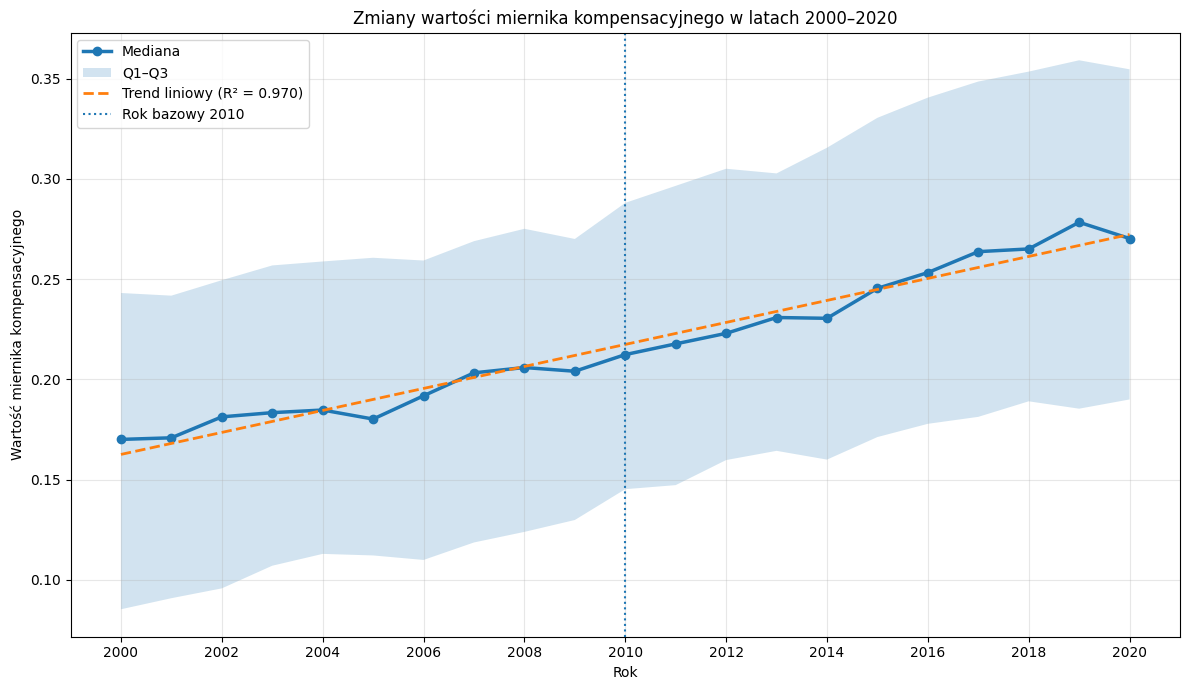

Zmiana trendu na rok: 0.005486
R²: 0.9701


In [21]:
x = trend["Year"].to_numpy()
y = trend["mediana"].to_numpy()

a, b = np.polyfit(x, y, 1)
trend_linear = a * x + b

ss_res = np.sum((y - trend_linear) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)

plt.figure(figsize=(12, 7))

plt.plot(
    trend["Year"],
    trend["mediana"],
    linewidth=2.5,
    marker="o",
    label="Mediana"
)

plt.fill_between(
    trend["Year"],
    trend["q1"],
    trend["q3"],
    alpha=0.2,
    label="Q1–Q3"
)

plt.plot(
    x,
    trend_linear,
    linestyle="--",
    linewidth=2,
    label=f"Trend liniowy (R² = {r2:.3f})"
)

plt.axvline(
    2010,
    linestyle=":",
    linewidth=1.5,
    label="Rok bazowy 2010"
)

plt.xticks(range(2000, 2021, 2))
plt.xlabel("Rok")
plt.ylabel("Wartość miernika kompensacyjnego")

plt.title(
    "Zmiany wartości miernika kompensacyjnego "
    "w latach 2000–2020"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Zmiana trendu na rok: {a:.6f}")
print(f"R²: {r2:.4f}")

### zmiana rankingu vs zmiana wartości q

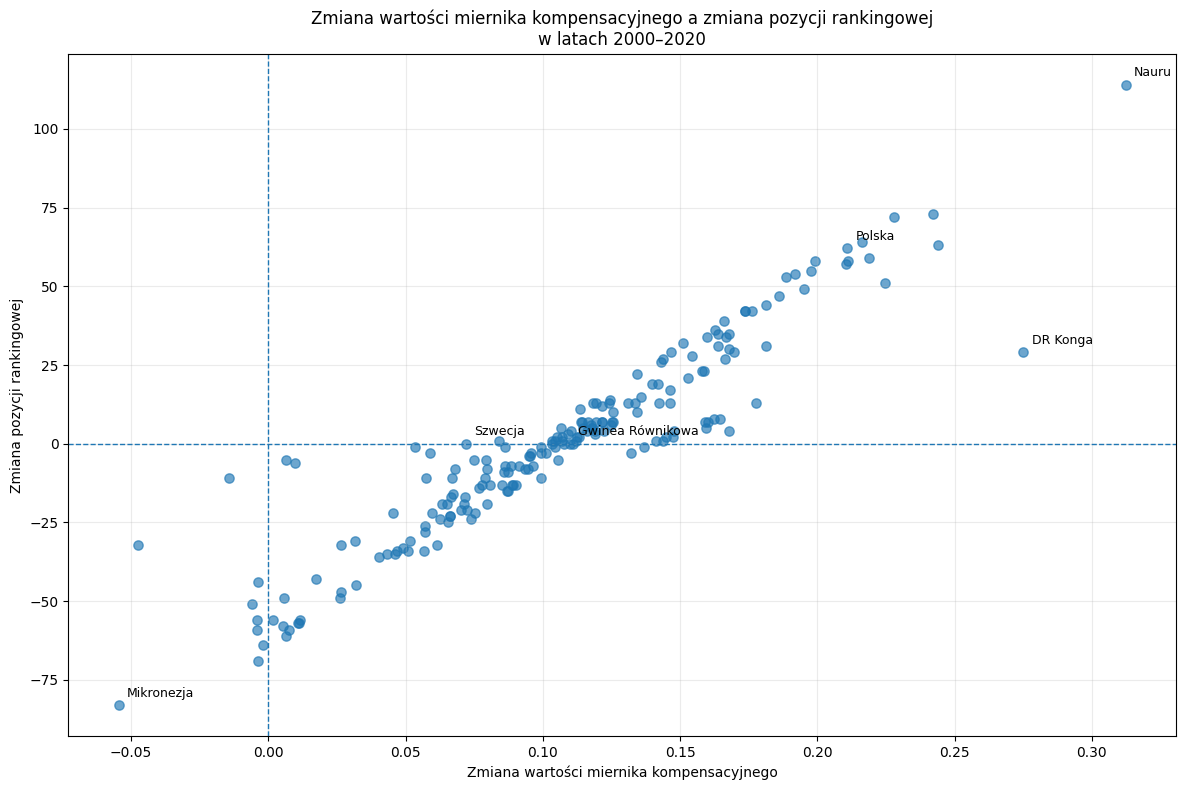

In [22]:
scatter_data = hellwig_all_years.copy()

scatter_data["rank"] = (
    scatter_data
    .groupby("Year")["q"]
    .rank(ascending=False, method="min")
)

scatter_2000 = (
    scatter_data[scatter_data["Year"] == 2000]
    [["Country Name", "q", "rank"]]
    .rename(columns={
        "q": "q_2000",
        "rank": "rank_2000"
    })
)

scatter_2020 = (
    scatter_data[scatter_data["Year"] == 2020]
    [["Country Name", "q", "rank"]]
    .rename(columns={
        "q": "q_2020",
        "rank": "rank_2020"
    })
)

comparison = scatter_2000.merge(
    scatter_2020,
    on="Country Name"
)

comparison["zmiana_q"] = (
    comparison["q_2020"] - comparison["q_2000"]
)

comparison["zmiana_rankingu"] = (
    comparison["rank_2000"] - comparison["rank_2020"]
)

plt.figure(figsize=(12, 8))

plt.scatter(
    comparison["zmiana_q"],
    comparison["zmiana_rankingu"],
    alpha=0.65,
    s=45
)

plt.axvline(0, linewidth=1, linestyle="--")
plt.axhline(0, linewidth=1, linestyle="--")

countries_to_label = {
    "Sweden": "Szwecja",
    "Poland": "Polska",
    "Nauru": "Nauru",
    "Congo, Dem. Rep.": "DR Konga",
    "Micronesia, Fed. Sts.": "Mikronezja",
    "Equatorial Guinea": "Gwinea Równikowa"
}

for country, label in countries_to_label.items():
    row = comparison[comparison["Country Name"] == country]

    if not row.empty:
        x = row["zmiana_q"].iloc[0]
        y = row["zmiana_rankingu"].iloc[0]

        plt.annotate(
            label,
            (x, y),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9
        )

plt.xlabel("Zmiana wartości miernika kompensacyjnego")
plt.ylabel("Zmiana pozycji rankingowej")

plt.title(
    "Zmiana wartości miernika kompensacyjnego a zmiana pozycji rankingowej\n"
    "w latach 2000–2020"
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### przebieg wartości 

In [23]:
selected_countries = [
    "Sweden",
    "Nauru",
    "Micronesia, Fed. Sts.",
    "Cameroon",
    "Congo, Dem. Rep.",
    "Poland"
]

traj = hellwig_all_years[
    hellwig_all_years["Country Name"].isin(selected_countries)
].copy()

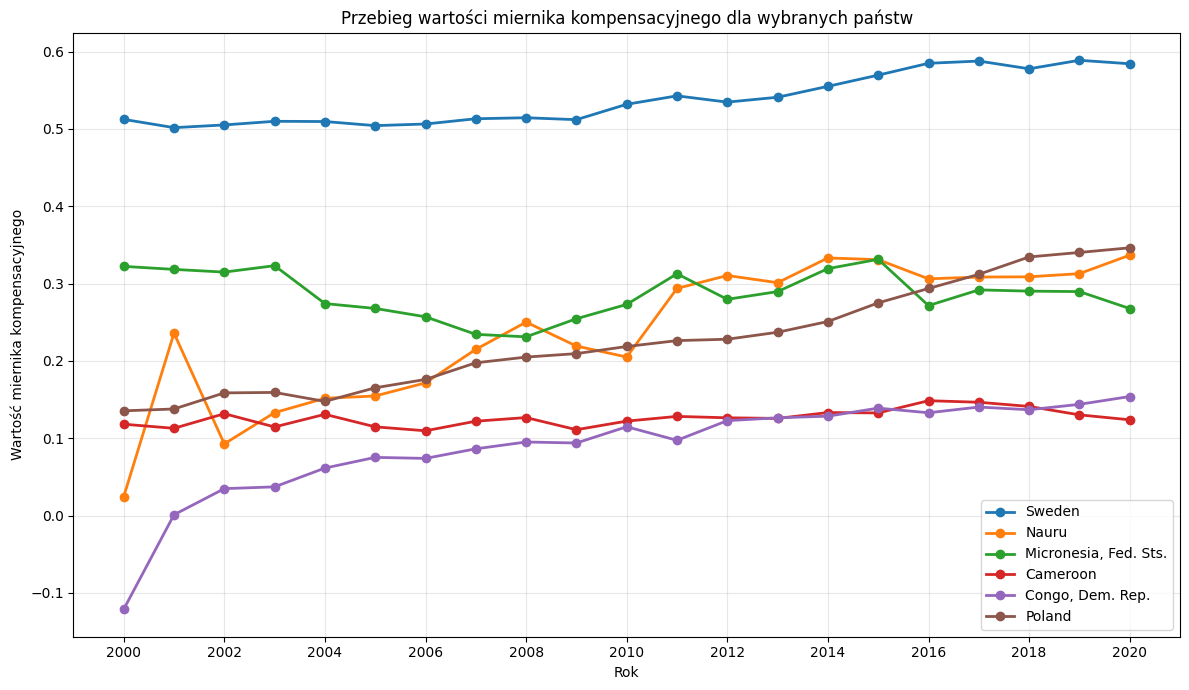

In [24]:
plt.figure(figsize=(12, 7))

for country in selected_countries:
    df_country = traj[traj["Country Name"] == country].sort_values("Year")
    
    plt.plot(
        df_country["Year"],
        df_country["q"],
        marker="o",
        linewidth=2,
        label=country
    )


plt.xticks(range(2000, 2021, 2))
plt.xlabel("Rok")
plt.ylabel("Wartość miernika kompensacyjnego")
plt.title("Przebieg wartości miernika kompensacyjnego dla wybranych państw")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()